# Pretraining on unlabeled data


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBac

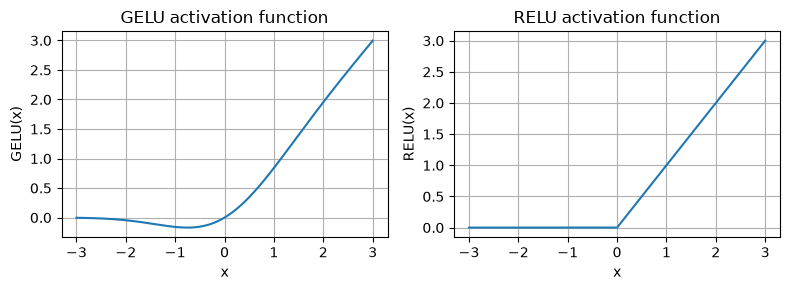

torch.Size([2, 3, 768])
layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606
layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472
attention scores 2 tensor([0., 0., 0., 0., 0., 0.])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attentions weights:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum tensor(1.0000)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum tensor(1.)
Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: 

In [1]:
import importnb
with importnb.Notebook():
    from chapter4 import GPTModel

GPT_CONFIG_124m = {
    "vocab_size": 50_257,   # number of unique token IDs the tokenizer/model supports
    "context_length": 256, # maximum number of tokens the model can process at once
    "emb_dim": 768,         # size of each token and postional embedding
    "n_heads": 12,          # number of attention heads in each multi-head attention layer
    "n_layers": 12,         # number of transformer blocks stacked in the model
    "drop_rate": 0.1,       # dropout probability used for regularization
    "qkv_bias": False,      # whether query/key/value linear layers use bias terms.
}

In [7]:
import torch
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124m)

In [8]:
# import gc
# del model
# gc.collect()

In [13]:
import tiktoken

def generate_text_simple(model, idx, max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1 )
    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model, 
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124m["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you dialect Suggestlikesurface holidays Hurricanes universal investigativeUnix Funny


In [14]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [17]:
import torch 
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token ids:\n", token_ids)

Token ids:
 tensor([[[32063],
         [13866],
         [22805]],

        [[37429],
         [29669],
         [27596]]])


In [20]:
print(f"Targets batch 1: {token_ids_to_text(targets[0],tokenizer)}")
print(f"Outputs batch 1: \n {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: 
  blendedbagefinder


In [33]:
torch.set_printoptions(sci_mode=False)
text_id = 0
target_probas_1 = probas[text_id, [0,1,2], targets[text_id]]
print(target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print(target_probas_2)


tensor([    0.0000,     0.0000,     0.0000])
tensor([    0.0000,     0.0001,     0.0000])


In [34]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([-10.1077, -10.3127, -11.4374, -10.8923,  -9.1719, -12.0331])


In [37]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.6592)


In [38]:
negative_avg_log_probas = avg_log_probas * -1

In [40]:
print(negative_avg_log_probas)

tensor(10.6592)


In [42]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [46]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])
tensor(10.6592)


In [48]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(42582.3438)


In [49]:
file_path = "training_text.txt"
with open(file_path, "r", encoding="utf8") as f:
    text_data = f.read()


In [50]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [51]:
import importnb
with importnb.Notebook(include_non_defs=False):
    from chapter2 import create_dataloader_v1

In [57]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [58]:
torch.manual_seed(123)
train_loader =  create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124m["context_length"],
    stride=GPT_CONFIG_124m["context_length"],
    drop_last=True,
    suffle=True,
    num_workers=0
)

val_loader =  create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124m["context_length"],
    stride=GPT_CONFIG_124m["context_length"],
    drop_last=True,
    suffle=True,
    num_workers=0
)

256 256
256 256


In [60]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

 Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [61]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss


In [ ]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches



In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f"Training loss: {train_loss}")
print(f"Validation loss: {val_loss}")

NameError: name 'calc_loss_bath' is not defined